Extracting geology map from the Australian Antarctic Database

In [6]:
import os
import zipfile
import geopandas as gpd

# Point to locally downloaded but uploaded to github zip folder
local_file = "/Users/jamessampson/Git/AT3_Group2_2026/Input_Data/Geology/Heard_Island_Geology_Map.zip"  
OUTPUT_DIR = "heard_island_geology"

os.makedirs(OUTPUT_DIR, exist_ok=True)

if zipfile.is_zipfile(local_file):
    extract_to = os.path.join(OUTPUT_DIR, "extracted")
    with zipfile.ZipFile(local_file) as z:
        z.extractall(extract_to)
    search_dir = extract_to
else:
    search_dir = os.path.dirname(local_file)

# Find and load whatever spatial file is in there
shapefiles, gdbs = [], []
for root, dirs, files in os.walk(search_dir):
    for d in dirs:
        if d.lower().endswith(".gdb"):
            gdbs.append(os.path.join(root, d))
    for f in files:
        if f.lower().endswith(".shp"):
            shapefiles.append(os.path.join(root, f))

print("Shapefiles found:", shapefiles)
print("Geodatabases found:", gdbs)

if shapefiles:
    gdf = gpd.read_file(shapefiles[0])
    print(gdf.head())
    print(f"CRS: {gdf.crs}")
elif gdbs:
    import fiona
    layers = fiona.listlayers(gdbs[0])
    print("Layers in geodatabase:", layers)
    gdf = gpd.read_file(gdbs[0], layer=layers[0])
    print(gdf.head())

Shapefiles found: ['heard_island_geology/extracted/Big Ben Lines.shp', 'heard_island_geology/extracted/Ar_dates.shp', 'heard_island_geology/extracted/HI_Geology_poly.shp', 'heard_island_geology/extracted/hi_contours.shp', 'heard_island_geology/extracted/HI_Outline.shp', 'heard_island_geology/extracted/contours_20m.shp', 'heard_island_geology/extracted/contours_20m_2.shp']
Geodatabases found: ['heard_island_geology/extracted/AADC_Fox_Heard.gdb']
   Id                                           geometry
0   0  LINESTRING (401858.12 4116799.288, 402040.021 ...
1   0  LINESTRING (399195.745 4117725.332, 398848.478...
2   0  LINESTRING (398517.749 4117361.529, 398153.946...
3   0  LINESTRING (399377.646 4116666.996, 399096.526...
4   0  LINESTRING (404272.448 4115294.467, 404459.879...
CRS: EPSG:32743


Extract DEM - A 10m DEM from the Australian Antarctic Data Centre

In [7]:
import rasterio

# Point to locally downloaded but uploaded to github zip folder
local_file = "/Users/jamessampson/Git/AT3_Group2_2026/Input_Data/Rectified_RADARSAT_image_of_Heard_Island_acquired_January_2002.zip"
OUTPUT_DIR = "heard_island_dem"

os.makedirs(OUTPUT_DIR, exist_ok=True)

if zipfile.is_zipfile(local_file):
    extract_to = os.path.join(OUTPUT_DIR, "extracted")
    with zipfile.ZipFile(local_file) as z:
        z.extractall(extract_to)
    search_dir = extract_to
else:
    search_dir = os.path.dirname(local_file)

# Find raster files (case-insensitive extension match)
rasters = []
for root, dirs, files in os.walk(search_dir):
    for f in files:
        if f.lower().endswith((".tif", ".tiff")):
            rasters.append(os.path.join(root, f))

print("Raster files found:", rasters)

# Prefer the 16-bit version (real elevation values) over any 8-bit display version
dem_path = next((r for r in rasters if "16bit" in r.lower()), rasters[0] if rasters else None)

if dem_path:
    print("Using:", dem_path)
    dem = rasterio.open(dem_path)
    elevation = dem.read(1)
    print(f"CRS: {dem.crs}")
    print(f"Shape: {elevation.shape}")
    print(f"Min/Max elevation: {elevation.min()} / {elevation.max()}")
else:
    print("No raster found.")

Raster files found: ['heard_island_dem/extracted/Corrected_16BIT.TIF', 'heard_island_dem/extracted/Corrected_8BIT.TIF']
Using: heard_island_dem/extracted/Corrected_16BIT.TIF
CRS: EPSG:32743
Shape: (5215, 5298)
Min/Max elevation: 0 / 65535


/var/folders/1x/09mps0nx4y3b27qt1lsjkbxr0000gn/T/ipykernel_62485/4017316736.py:32: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  elevation = dem.read(1)


Derive slope from DEM

In [12]:
#Slope function
from osgeo import gdal
import os

gdal.UseExceptions()


def slope(dem_path, out_path, units="degree", scale=None, compute_edges=True):
    """Slope raster. units: 'degree' or 'percent'."""
    opts = gdal.DEMProcessingOptions(
        slopeFormat=units,
        scale=scale,
        computeEdges=compute_edges,
        creationOptions=["COMPRESS=LZW"],
    )
    gdal.DEMProcessing(out_path, dem_path, "slope", options=opts)
    return out_path


Derive aspect from DEM

In [9]:
#Aspect function
def aspect(dem_path, out_path, zero_for_flat=False, compute_edges=True):
    """Aspect in degrees clockwise from north. Flat cells are nodata (-9999)
    unless zero_for_flat=True."""
    opts = gdal.DEMProcessingOptions(
        zeroForFlat=zero_for_flat,
        computeEdges=compute_edges,
        creationOptions=["COMPRESS=LZW"],
    )
    gdal.DEMProcessing(out_path, dem_path, "aspect", options=opts)
    return out_path

Derive hillshade from DEM

In [10]:
#Hillshade function
def hillshade(dem_path, out_path, azimuth=315, altitude=45, z_factor=1.0,
              scale=None, multi_directional=False, combined=False,
              compute_edges=True):
    """Hillshade (0-255). Set multi_directional=True for a softer,
    multi-light-source look that works well in rugged terrain."""
    opts = gdal.DEMProcessingOptions(
        azimuth=azimuth,
        altitude=altitude,
        zFactor=z_factor,
        scale=scale,
        multiDirectional=multi_directional,
        combined=combined,
        computeEdges=compute_edges,
        creationOptions=["COMPRESS=LZW"],
    )
    gdal.DEMProcessing(out_path, dem_path, "hillshade", options=opts)
    return out_path

Now to plug in the DEM and use these functions

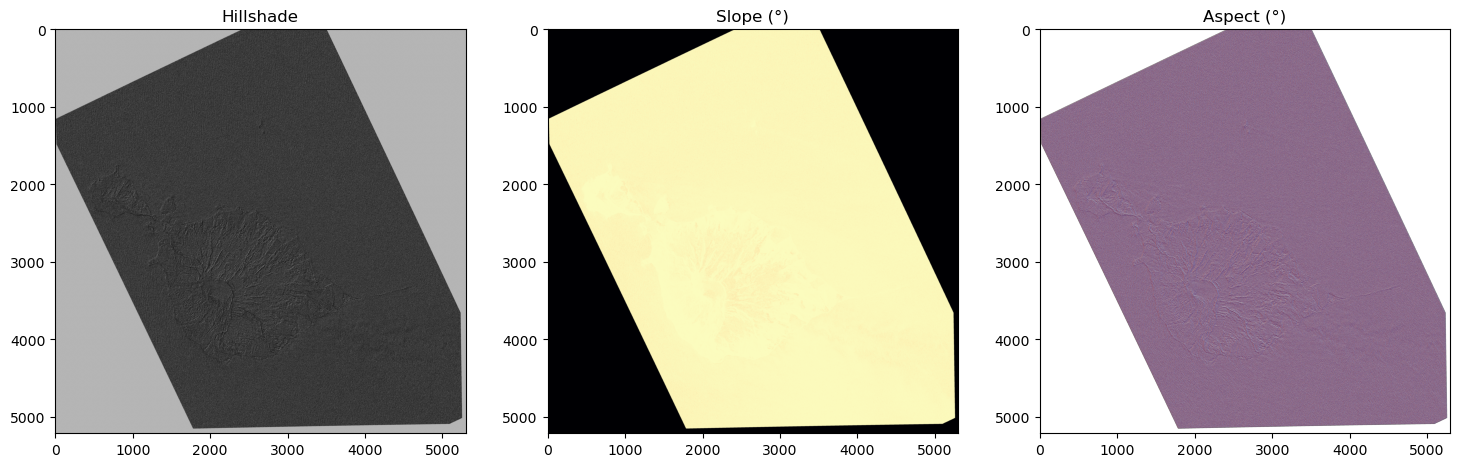

In [11]:
slope_path = slope(dem_path, os.path.join(OUTPUT_DIR, "slope.tif"))
aspect_path = aspect(dem_path, os.path.join(OUTPUT_DIR, "aspect.tif"))
hillshade_path = hillshade(dem_path, os.path.join(OUTPUT_DIR, "hillshade.tif"))

#And to plot these rasters
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def read_masked(path):
    with rasterio.open(path) as src:
        a = src.read(1, masked=True)   # nodata automatically masked
    return a

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(read_masked(hillshade_path), cmap="gray");      ax[0].set_title("Hillshade")
ax[1].imshow(read_masked(slope_path), cmap="magma");         ax[1].set_title("Slope (°)")
ax[2].imshow(read_masked(aspect_path), cmap="twilight");     ax[2].set_title("Aspect (°)")
plt.show()